In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier

# Load data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# Initialize a classifier
clf = TabPFNClassifier(
    n_estimators=1,
    inference_config=dict(POLYNOMIAL_FEATURES="no", FINGERPRINT_FEATURE=False),
)
clf.fit(X_train, y_train)

# Predict probabilities
prediction_probabilities = clf.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, prediction_probabilities[:, 1]))

# Predict labels
predictions = clf.predict(X_test)
print("Accuracy", accuracy_score(y_test, predictions))

ROC AUC: 0.9977081741787623
Accuracy 0.9754385964912281


In [2]:
X_test.shape

(285, 30)

In [7]:
X_train.shape

(284, 30)

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNRegressor

# Load Boston Housing data
df = fetch_openml(data_id=531, as_frame=True)  # Boston Housing dataset
X = df.data
y = df.target.astype(float)  # Ensure target is float for regression

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# Initialize the regressor
regressor = TabPFNRegressor(n_estimators=1)
regressor.fit(X_train, y_train)

# Predict on the test set
predictions = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 10.912531776958316
R² Score: 0.865493698991233


In [10]:
print(regressor.model_)

PerFeatureTransformer(
  (encoder): SequentialEncoder(
    (0): RemoveEmptyFeaturesEncoderStep()
    (1): NanHandlingEncoderStep()
    (2): VariableNumFeaturesEncoderStep()
    (3): InputNormalizationEncoderStep()
    (4): VariableNumFeaturesEncoderStep()
    (5): LinearInputEncoderStep(
      (layer): Linear(in_features=4, out_features=192, bias=False)
    )
  )
  (y_encoder): SequentialEncoder(
    (0): NanHandlingEncoderStep()
    (1): LinearInputEncoderStep(
      (layer): Linear(in_features=2, out_features=192, bias=True)
    )
  )
  (transformer_encoder): LayerStack(
    (layers): ModuleList(
      (0-11): 12 x PerFeatureEncoderLayer(
        (self_attn_between_features): MultiHeadAttention()
        (self_attn_between_items): MultiHeadAttention()
        (mlp): MLP(
          (linear1): Linear(in_features=192, out_features=768, bias=False)
          (linear2): Linear(in_features=768, out_features=192, bias=False)
        )
        (layer_norms): ModuleList(
          (0-2): 3 x 

In [12]:
model = regressor.model_

In [13]:
type(model)

tabpfn.architectures.base.transformer.PerFeatureTransformer

In [18]:
model.transformer_encoder.layers[0].self_attn_between_features

MultiHeadAttention()

In [5]:
activations = {}


def get_activation(name):
    def hook(model, input, output):
        # For Transformer blocks, 'output' is often a tuple.
        # We're usually interested in the first element (the hidden states).
        activations[name] = output[0].detach()
        print(activations[name].shape)

    return hook


hook_handles = []
for i, layer in enumerate(model.transformer_encoder.layers):
    if i == 0:
        handle = layer.register_forward_hook(get_activation("layer_0"))
        hook_handles.append(handle)

with torch.no_grad():
    prediction_probabilities = clf.predict_proba(X_test[0:1])

for handle in hook_handles:
    handle.remove()

/home/aviral2022/projects/tabfm_interp/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but TabPFNClassifier was fitted without feature names
  warnings.warn(


ValueError: X has 13 features, but TabPFNClassifier is expecting 30 features as input.

In [4]:
activations["layer_0"].shape

NameError: name 'activations' is not defined

In [ ]:
# Let's debug why we're getting multiple prints

activations = {}
call_counts = {}


def get_activation(name):
    def hook(model, input, output):
        # Count how many times each layer is called
        if name not in call_counts:
            call_counts[name] = 0
        call_counts[name] += 1

        # For Transformer blocks, 'output' is often a tuple.
        # We're usually interested in the first element (the hidden states).
        activations[name] = output[0].detach()
        print(
            f"Layer {name} called {call_counts[name]} times, shape: {activations[name].shape}"
        )

    return hook


hook_handles = []
for i, layer in enumerate(model.transformer_encoder.layers):
    handle = layer.register_forward_hook(get_activation(f"layer_{i}"))
    hook_handles.append(handle)

print("Calling predict_proba...")
prediction_probabilities = clf.predict_proba(X_test[0:1])

print("\nTotal calls per layer:")
for layer_name, count in call_counts.items():
    print(f"{layer_name}: {count} calls")

for handle in hook_handles:
    handle.remove()

Calling predict_proba...
Layer layer_0 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_1 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_2 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_3 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_4 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_5 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_6 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_7 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_8 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_9 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_10 called 1 times, shape: torch.Size([285, 39, 192])
Layer layer_11 called 1 times, shape: torch.Size([285, 39, 192])

Total calls per layer:
layer_0: 1 calls
layer_1: 1 calls
layer_2: 1 calls
layer_3: 1 calls
layer_4: 1 calls
layer_5: 1 calls
layer_6: 1 calls
layer_7: 1 calls
layer_8: 1 calls
layer_9: 1 calls
layer_10: 1

In [ ]:
activations["layer_0"].shape

KeyError: 'layer_0'

In [7]:
# trying shit out
type(model)

tabpfn.architectures.base.transformer.PerFeatureTransformer

In [10]:
type(regressor)

tabpfn.regressor.TabPFNRegressor

In [3]:
regressor.model_

PerFeatureTransformer(
  (encoder): SequentialEncoder(
    (0): RemoveEmptyFeaturesEncoderStep()
    (1): NanHandlingEncoderStep()
    (2): VariableNumFeaturesEncoderStep()
    (3): InputNormalizationEncoderStep()
    (4): VariableNumFeaturesEncoderStep()
    (5): LinearInputEncoderStep(
      (layer): Linear(in_features=4, out_features=192, bias=False)
    )
  )
  (y_encoder): SequentialEncoder(
    (0): NanHandlingEncoderStep()
    (1): LinearInputEncoderStep(
      (layer): Linear(in_features=2, out_features=192, bias=True)
    )
  )
  (transformer_encoder): LayerStack(
    (layers): ModuleList(
      (0-11): 12 x PerFeatureEncoderLayer(
        (self_attn_between_features): MultiHeadAttention()
        (self_attn_between_items): MultiHeadAttention()
        (mlp): MLP(
          (linear1): Linear(in_features=192, out_features=768, bias=False)
          (linear2): Linear(in_features=768, out_features=192, bias=False)
        )
        (layer_norms): ModuleList(
          (0-2): 3 x 

In [3]:
# plotting the bar distribution
regressor.bardist_.borders[:-1] + regressor.bardist_.bucket_widths / 2

tensor([-59.6094, -24.3822, -21.9030,  ...,  22.7351,  25.4253,  57.0489],
       device='cuda:0')

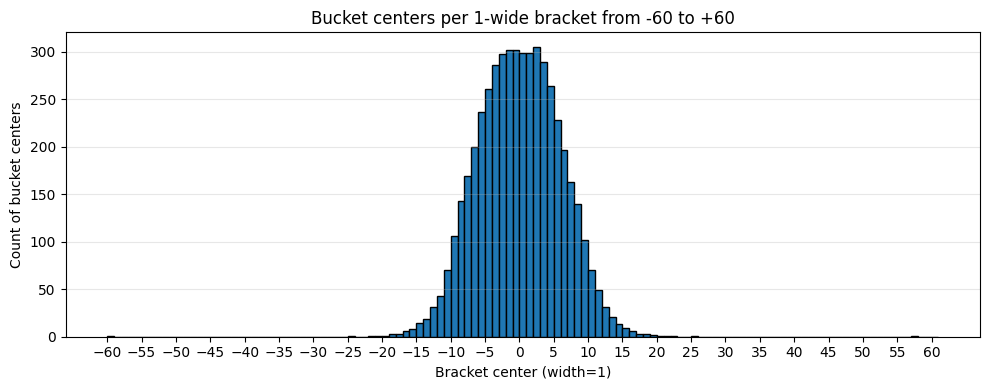

[-60, -59): 1
[-25, -24): 1
[-22, -21): 1
[-21, -20): 1
[-20, -19): 1
[-19, -18): 3
[-18, -17): 3
[-17, -16): 6
[-16, -15): 8
[-15, -14): 14
[-14, -13): 19
[-13, -12): 31
[-12, -11): 43
[-11, -10): 70
[-10, -9): 106
[-9, -8): 143
[-8, -7): 169
[-7, -6): 200
[-6, -5): 236
[-5, -4): 261
[-4, -3): 286
[-3, -2): 297
[-2, -1): 302
[-1, 0): 302
[0, 1): 299
[1, 2): 298
[2, 3): 305
[3, 4): 289
[4, 5): 264
[5, 6): 228
[6, 7): 196
[7, 8): 163
[8, 9): 140
[9, 10): 102
[10, 11): 70
[11, 12): 49
[12, 13): 31
[13, 14): 21
[14, 15): 13
[15, 16): 9
[16, 17): 6
[17, 18): 3
[18, 19): 3
[19, 20): 2
[20, 21): 1
[21, 22): 1
[22, 23): 1
[25, 26): 1
[57, 58): 1


In [ ]:
# seeing distribution of bucket centers for the regressor
# its roughly normal
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assuming regressor is already fitted
borders = regressor.bardist_.borders  # torch.Tensor
bucket_widths = regressor.bardist_.bucket_widths  # scalar/tensor

# Compute bucket centers
bucket_centers = borders[:-1] + bucket_widths / 2
bucket_centers = torch.as_tensor(bucket_centers).detach().cpu().numpy()

# Define 1-wide bins from -60 to +60 (inclusive of -60 to 60)
# Edges go from -60 to +61 so the last bin is [60, 61)
bin_edges = np.arange(-60, 61 + 1, 1)

# Histogram counts of centers falling into each 1-wide bracket
counts, edges = np.histogram(bucket_centers, bins=bin_edges)

# Plot
bin_centers_for_plot = (edges[:-1] + edges[1:]) / 2.0
plt.figure(figsize=(10, 4))
plt.bar(bin_centers_for_plot, counts, width=1.0, align="center", edgecolor="k")
plt.xlabel("Bracket center (width=1)")
plt.ylabel("Count of bucket centers")
plt.title("Bucket centers per 1-wide bracket from -60 to +60")
plt.xticks(np.arange(-60, 61, 5))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print a few bracket counts
for c, left in zip(counts, edges[:-1]):
    if c > 0 and (-60 <= left < 61):
        print(f"[{int(left)}, {int(left) + 1}): {c}")

In [2]:
import numpy as np
import torch


def set_seed(seed):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


set_seed(42)
random = np.random.randn(1)
print(random)

[0.49671415]
